# Python for (Open) Neuroscience  
### Lecture 2.1 — Numpy: Arrays, types, indexing
#### Module 02 - Scientific stack

Sara Assecondi

Department of Psychology and Cognitive Sciences

>**Goal of this lecture:** introduce `numpy.ndarray` as the core data structure for scientific computing, then make students comfortable creating arrays, inspecting them, indexing them, and understanding views vs copies.

> [Website](https://numpy.org/)   
> [Documentation](https://numpy.org/doc/)
---

## Lecture outline

- Importing libraries and the role of NumPy
- What an `ndarray` is
- Creating arrays
- Dtypes, `np.nan`, and memory considerations
- Array attributes: `.shape`, `.ndim`, `.dtype`, `.size`
- Indexing and slicing
- Boolean and fancy indexing
- Views vs copies
- Singleton dimensions and `np.newaxis`
- Quick visualization with `matplotlib`


## NumPy

NumPy is the standard Python library for **array programming**.

It is useful because:
- arrays are memory-efficient,
- operations are fast,
- indexing is powerful,
- it supports vectorized scientific code,
- it is the foundation of many other libraries used in neuroscience.


For NumPy, the standard alias is `np`.

In [5]:
import numpy as np
print("numpy version " + np.__version__)

numpy version 2.4.3


if you need to install it:

    conda activate python-cimec
    conda install -c conda-forge numpy
    
check that it works

    python -c "import numpy as np; print(np.__version__)"

## The numpy object: `np.ndarray`

`numpy.ndarray` is the main NumPy data structure.

- it can represent 1D, 2D, 3D, ... N-dimensional data,
- all elements share the same data type,
- most operations are designed to work efficiently over entire arrays.


In [6]:
# 1D array
np.array([1, 2, 3, 4])

array([1, 2, 3, 4])

In [11]:
# 2D array
np.array([[1, 2, 3],
          [4, 5, 6]])

array([[1, 2, 3],
       [4, 5, 6]])

- outer list = rows
- inner lists = each row
- shape is (2, 3)

### Initialize arrays

#### Arrays filled with zeros, ones, or constants


In [ ]:
# array of zeros
np.zeros(5)

In [ ]:
# array of ones
np.ones((3, 2))


In [12]:
# array of elements of the same value
np.full((2, 3), 7)

array([[7, 7, 7],
       [7, 7, 7]])

#### Regular numeric sequences

In [ ]:
np.arange(10)          # 0 to 9

In [ ]:
np.arange(1, 10, 2)    # start, stop, step

In [ ]:
np.linspace(0, 1, 5)   # 5 equally spaced values including both ends

#### Random arrays

In [15]:
np.random.randint(0, 10, (3, 4))

array([[6, 6, 8, 4],
       [7, 2, 2, 3],
       [1, 1, 7, 3]])

In [16]:
np.random.normal(0, 1, (2, 5))

array([[-0.5486754 , -0.75955891, -0.15893011, -0.89988671, -0.33070294],
       [ 0.82071597,  0.32371646, -0.9078522 , -2.38502533, -0.75062402]])

### Types of values in arrays

Unlike Python lists, NumPy arrays are **homogeneous**: one array has one dtype.


In [17]:
a = np.ones((2, 3))
a

array([[1., 1., 1.],
       [1., 1., 1.]])

In [18]:
a.dtype

dtype('float64')

In [19]:
np.zeros((2, 3), dtype=bool)

array([[False, False, False],
       [False, False, False]])

In [20]:
np.array([1, 2, 3], dtype=np.uint8)

array([1, 2, 3], dtype=uint8)

#### Memory-efficient types

We can also use some special data type from numpy, for memory saving purposes:
 - `np.uint8` (numbers from 0 to 255)
 - `np.int8` (numbers from -128 to 127)
 - `np.uint16` (numbers from 0 to 65535)
 - `np.int16` (numbers from -32768 to 32767)
 
The number (8 or 16) represents the number of **bits** used for every entry in the array!

For **large datasets**, choosing the right dtype **matters**.

In [51]:

a_int64 = np.ones((200, 300), dtype=int)
a_uint8 = np.ones((200, 300), dtype=np.uint8)

print(a_int64.nbytes, "bytes")
print(a_uint8.nbytes, "bytes")


480000 bytes
60000 bytes


#### Changing dtype


In [52]:
a = np.array([1.2, 2.7, 3.5])
print(a)

a.astype(int)
print(a.dtype)

[1.2 2.7 3.5]
float64


#### Missing values: `np.nan`

`np.nan` is commonly used to represent missing numerical data.


In [ ]:
a = np.full((2, 3), np.nan)
a

#### Arrays of text
We can also make arrays of text!

In [31]:
txt = np.full((3,2), "some text")

print(txt) 

# look at the dtype! the number you read will be the number of characters:
print(txt.dtype)

[['some text' 'some text']
 ['some text' 'some text']
 ['some text' 'some text']]
<U9


### Useful array attributes

In [32]:

arr = np.zeros((4, 3, 5))
print("ndim:", arr.ndim)    # number of dimensions
print("shape:", arr.shape)  # number of element in each dimension
print("dtype:", arr.dtype)  # data type
print("size:", arr.size)    # number of elemnet in the whole matrix


ndim: 3
shape: (4, 3, 5)
dtype: float64
size: 60


### Converting lists to arrays

In [34]:
my_list = [1, 2, 3, 4]

a= np.array(my_list)
print(a.shape)

(4,)


We can also convert a list of lists, this will add dimensions.

In [33]:
my_list = [[1, 2, 3],
           [4, 5, 6]]

a = np.array(my_list)
print(a.shape)

(2, 3)


In [68]:
my_list = [[1, 2, 3],
           [4, 5]]

a = np.array(my_list)
print(a.shape)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

**Important:** nested lists should have compatible lengths if you want a proper rectangular array.


### Reshaping arrays

`reshape` changes the shape of an array without changing its data.

- It reorganizes the same elements into a new shape
- The total number of elements must stay the same
- It is one of the most important tools for working with NumPy arrays
- It helps move between 1D, 2D, and higher-dimensional representations

In [69]:
a = np.arange(12)
print(a)
# [ 0  1  2  3  4  5  6  7  8  9 10 11]

b = a.reshape(3, 4)
print(b)

[ 0  1  2  3  4  5  6  7  8  9 10 11]
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]


`reshape(3, 4)` works because `3 × 4 = 12`, which matches the number of elements.

- `reshape()` changes how values are arranged **across the axes**, but it does not change the values themselves.
- the number of elements (`size`) stays the same

- in 2D:
    - axis 0 → rows
    - axis 1 → columns

- in 3D
    - axis 0 → blocks
    - axis 1 → rows
    - axis 2 → columns

### Indexing arrays

In [83]:
v = np.arange(10)
v

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

#### Basic indexing and slicing

In [84]:
# one element
n = v[0]

print(n)
print(n.dtype)
print(n.shape)

0
int64
()


In [85]:
# a range of elements
n = v[2:6]

print(n)
print(n.dtype)
print(n.shape)

[2 3 4 5]
int64
(4,)


In [86]:
# every other element (even elements)
n = v[::2]

print(n)
print(n.dtype)
print(n.shape)

[0 2 4 6 8]
int64
(5,)


In [87]:
# all odd elements
n = v[1::2]

print(n)
print(n.dtype)
print(n.shape)

[1 3 5 7 9]
int64
(5,)


In [49]:
# every other element backwards (start from 9) 
n = v[::-2]

print(n)
print(n.dtype)
print(n.shape)

[9 7 5 3 1]
int64
(5,)


In [53]:
# count from the end, last element of array
n = v[-1]

print(n)
print(n.dtype)
print(n.shape)

9
int64
()


#### Indexing with integer arrays/lists

In [59]:
v = np.array([10, 20, 30, 40, 50, 60, 70])
idx = [0, 2, 5]

print(v[idx])
print("shape of selection: " + str(v[idx].shape))
print("shape of index: " + str(len(idx)))

[10 30 60]
shape of selection: (3,)
shape of index: 3


#### Boolean indexing

In [60]:
v = np.array([1, 2, 3, 4, 5])
mask = v > 3
print(mask)
print(v[mask])

[False False False  True  True]
[4 5]


#### Multidimensional indexing

We can index over **multiple dimensions** specifying **comma-separated indexes** along each dimension.
> **! Remember** index starts from 0

In [94]:
m = np.array([[1, 2, 3, 4],
              [5, 6, 7, 8],
              [9,10,11,12]])

print("m = ", m)
print("m[1, 2] = ",m[1, 2])
print("m[0:2, 1:4] = ",m[0:2, 1:4])   
print("m[:, 0] = ",m[:, 0])
print("m[1, :] = ",m[1, :])

m =  [[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
m[1, 2] =  7
m[0:2, 1:4] =  [[2 3 4]
 [6 7 8]]
m[:, 0] =  [1 5 9]
m[1, :] =  [5 6 7 8]


#### Combining indexing

We can use any combination of indexes and boolean selectors for each axis, as long as the **dimension matches**:

In [95]:
x = np.arange(24).reshape(2, 3, 4)
x

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])

In [67]:
x[:, [0, 2], 1:3]

array([[[ 1,  2],
        [ 9, 10]],

       [[13, 14],
        [21, 22]]])

## Views vs copies

**Indexing and slicing** usually return a ***view***, not a copy.   
A **view** is another way of looking at the same underlying data in memory.

This means:

- the sliced array does **not** contain independent data
- it still refers to the **original array**
- if you change the slice, you also change the original array

In [72]:
a = np.array([1, 2, 3, 4, 5])
b = a[1:4]      # b is a view of a

# change the first element of b
b[0] = 99

print("b = ",b)
print("a = ",a)

b =  [99  3  4]
a =  [ 1 99  3  4  5]


<div style="background:#e6f2ff; padding:20px; border-radius:12px;">
This is useful for performance, but students need to remember that modifying a view can modify the original array.</div>


## Singleton dimensions and `np.newaxis`

A **singleton dimension**, i.e. dimensions along which there is a single entry,  has size 1.

Example:

- shape `(1,)` → singleton dimension
- shape `(3,)` → no singleton dimension
- shape `(1, 3)` → the first axis is a singleton dimension
- shape `(3, 1)` → the second axis is a singleton dimension
- shape `(2, 1, 4)` → the middle axis is a singleton dimension

So “singleton dimension” simply means:
**a dimension with only one position along that axis.**

In [ ]:
Sometimes, it can be useful to quickly add a singleton dimension:

In [75]:
# array
a = np.zeros(4)
print(a.shape)

b = a[:, np.newaxis]
print(b.shape)


(4,)
(4, 1)


In [76]:

c = a[np.newaxis, :]
print(c.shape)


(1, 4)


## Quick visualization

Arrays are easy to inspect visually.


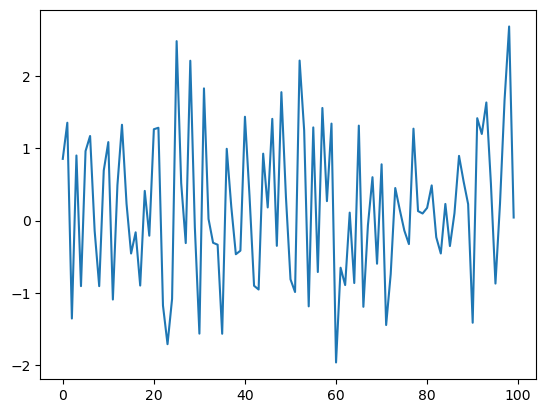

In [80]:
import matplotlib.pyplot as plt

signal = np.random.randn(100)
plt.plot(signal)
plt.show()


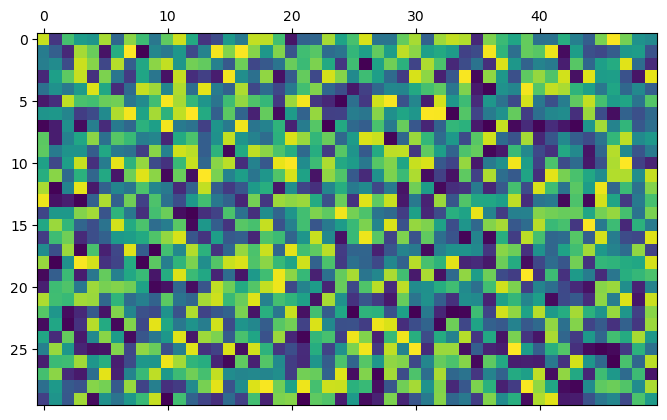

In [81]:

img = np.random.randint(0, 255, (30, 50))
plt.matshow(img)
plt.show()
